# 🚀 AlphaPulse — Interactive Exploration Notebook
**Use this notebook to test and understand each step before running the final scripts.**

▶️ Run each cell one by one using `Shift + Enter`

---
## 📦 CELL 1 — Install & Import Everything

In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
%matplotlib inline

# Dark theme for all charts
plt.rcParams['figure.facecolor'] = '#0d1117'
plt.rcParams['axes.facecolor']   = '#111827'
plt.rcParams['axes.labelcolor']  = 'white'
plt.rcParams['xtick.color']      = 'white'
plt.rcParams['ytick.color']      = 'white'
plt.rcParams['text.color']       = 'white'
plt.rcParams['grid.color']       = '#333'
plt.rcParams['axes.spines.top']  = False
plt.rcParams['axes.spines.right']= False

print('✅ All imports successful!')

✅ All imports successful!


---
## ⚙️ CELL 2 — Configuration

In [3]:
STOCKS = [
    'AAPL', 'MSFT', 'GOOGL',
    'JPM',  'BAC',
    'JNJ',  'PFE',
    'XOM',  'CVX',
    'AMZN'
]

START_DATE       = '2023-01-01'
END_DATE         = '2025-01-01'
MONTE_CARLO_RUNS = 10000
FORECAST_DAYS    = 252
ROLLING_WINDOW   = 30
CONFIDENCE_LEVEL = 0.95

COLORS = ['#2196F3','#FF5252','#69FF47','#FFD700',
          '#FF6B9D','#00E5FF','#FF9800','#E040FB','#76FF03','#F50057']

print(f'📊 Tracking {len(STOCKS)} stocks: {STOCKS}')
print(f'📅 Period: {START_DATE} to {END_DATE}')

📊 Tracking 10 stocks: ['AAPL', 'MSFT', 'GOOGL', 'JPM', 'BAC', 'JNJ', 'PFE', 'XOM', 'CVX', 'AMZN']
📅 Period: 2023-01-01 to 2025-01-01


---
## 📥 CELL 3 — Download Stock Data (Week 1)

In [4]:
print('📥 Downloading stock data from Yahoo Finance...')

raw_data = yf.download(STOCKS, start=START_DATE, end=END_DATE, auto_adjust=True)
close_prices = raw_data['Close']
close_prices.ffill(inplace=True)
close_prices.dropna(how='all', inplace=True)

print(f'\n✅ Downloaded {close_prices.shape[0]} days x {close_prices.shape[1]} stocks')
print(f'📅 From {close_prices.index[0].date()} to {close_prices.index[-1].date()}')
close_prices.tail(3)

📥 Downloading stock data from Yahoo Finance...


[*********************100%***********************]  10 of 10 completed


✅ Downloaded 502 days x 10 stocks
📅 From 2023-01-03 to 2024-12-31


Ticker,AAPL,AMZN,BAC,CVX,GOOGL,JNJ,JPM,MSFT,PFE,XOM
Date,,,,,,,,,,
2024-12-27,254.201370,223.750000,43.092690,136.287125,191.872925,139.997559,235.109985,426.404083,24.414877,102.030319
2024-12-30,250.829788,221.300003,42.674789,135.406967,190.359970,138.347107,233.306488,420.758698,24.231447,101.340416
2024-12-31,249.059464,219.389999,42.713657,137.082153,188.428879,139.582520,233.686691,417.460602,24.332335,103.074768


---
## 📈 CELL 4 — Plot Normalized Stock Prices

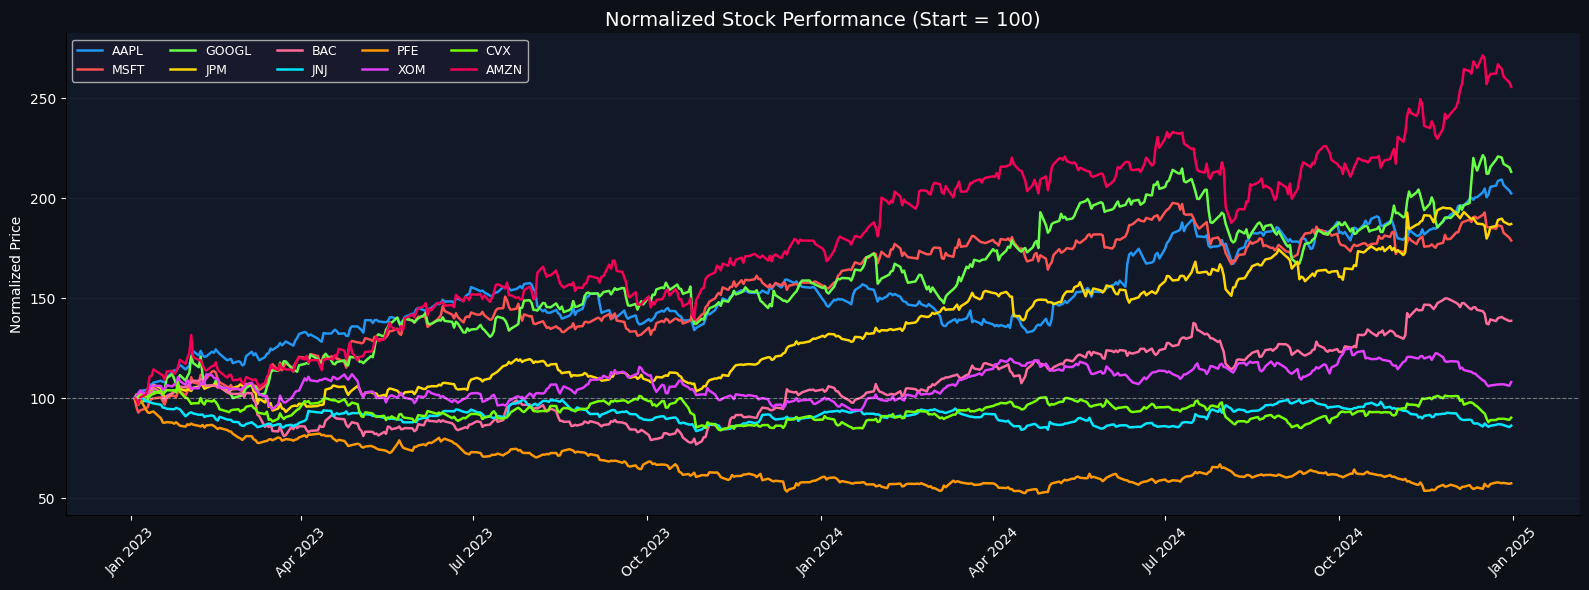

In [ ]:
normalized = (close_prices / close_prices.iloc[0]) * 100

fig, ax = plt.subplots(figsize=(16, 6))
for i, stock in enumerate(STOCKS):
    ax.plot(normalized.index, normalized[stock],
            label=stock, color=COLORS[i], linewidth=1.8)

ax.axhline(100, color='white', linewidth=0.8, linestyle='--', alpha=0.4)
ax.set_title('Normalized Stock Performance (Start = 100)', fontsize=14)
ax.set_ylabel('Normalized Price')
ax.legend(ncol=5, loc='upper left', facecolor='#1a1a2e', fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
## 📊 CELL 5 — Calculate Log Returns (Week 2)

In [ ]:
log_returns = np.log(close_prices / close_prices.shift(1))
log_returns.dropna(inplace=True)

print('--- Daily Return Statistics (%) ---')
display((log_returns * 100).describe().round(4))
print(f'\n✅ Log returns for {len(log_returns)} trading days calculated')

--- Daily Return Statistics (%) ---


Ticker,AAPL,AMZN,BAC,CVX,GOOGL,JNJ,JPM,MSFT,PFE,XOM
count,501.0000,501.0000,501.0000,501.0000,501.0000,501.0000,501.0000,501.0000,501.0000,501.0000
mean,0.1407,0.1873,0.0653,-0.0205,0.1511,-0.0295,0.1250,0.1160,-0.1108,0.0154
std,1.3414,1.9256,1.5614,1.3373,1.8401,0.9954,1.3898,1.4276,1.4635,1.3984
min,-4.9366,-9.1948,-6.4047,-6.9570,-9.9924,-4.0648,-6.6864,-6.2437,-6.9543,-5.1028
25%,-0.6603,-0.8917,-0.8220,-0.7761,-0.8947,-0.5214,-0.5244,-0.6830,-0.9659,-0.8740
50%,0.1648,0.0908,0.0000,0.0837,0.3003,0.0000,0.1893,0.1342,-0.1181,0.0090
75%,0.8945,1.3351,0.8641,0.7318,1.1036,0.4874,0.8091,0.9689,0.6863,0.8834
max,7.0131,7.9452,8.0924,4.7492,9.7348,5.8956,10.9254,6.9932,5.9108,5.7326



✅ Log returns for 501 trading days calculated


---
## 🔔 CELL 6 — Bell Curve (Return Distribution)

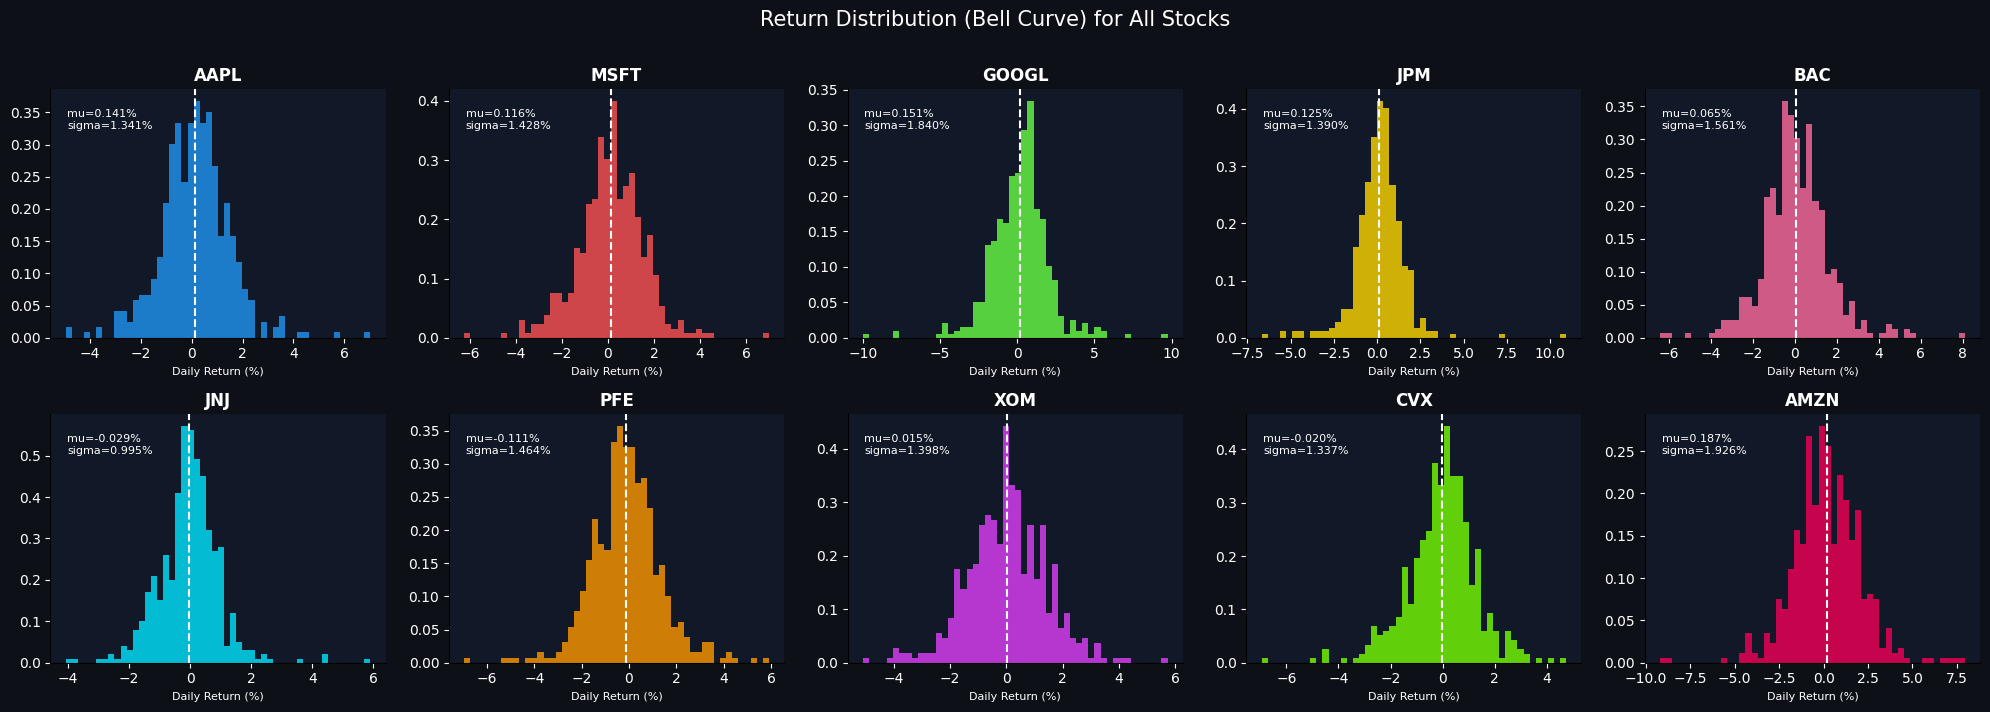

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
axes_flat = axes.flatten()

for i, stock in enumerate(STOCKS):
    ax = axes_flat[i]
    r = log_returns[stock] * 100
    ax.hist(r, bins=50, color=COLORS[i], alpha=0.8, edgecolor='none', density=True)
    ax.axvline(r.mean(), color='white', linewidth=1.5, linestyle='--')
    ax.set_title(stock, fontsize=12, fontweight='bold')
    ax.set_xlabel('Daily Return (%)', fontsize=8)
    ax.text(0.05, 0.92, f'mu={r.mean():.3f}%\nsigma={r.std():.3f}%',
            transform=ax.transAxes, fontsize=8, va='top')

fig.suptitle('Return Distribution (Bell Curve) for All Stocks', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
STOCK_TO_TEST = 'AAPL'  

r    = log_returns[STOCK_TO_TEST]
mean = r.mean()
std  = r.std()

print(f'Running {MONTE_CARLO_RUNS:,} simulations for {STOCK_TO_TEST}...')

np.random.seed(42)
all_paths = np.zeros((MONTE_CARLO_RUNS, FORECAST_DAYS))

for i in range(MONTE_CARLO_RUNS):
    daily_r      = np.random.normal(mean, std, FORECAST_DAYS)
    all_paths[i] = 100 * np.exp(np.cumsum(daily_r))

final_prices = all_paths[:, -1]
var_price    = np.percentile(final_prices, 5)
var_loss     = 100 - var_price

print(f'\n📊 {STOCK_TO_TEST} Results:')
print(f'  Starting         : $100.00')
print(f'  Median final     : ${np.median(final_prices):.2f}')
print(f'  Best case  (95%) : ${np.percentile(final_prices, 95):.2f}')
print(f'  Worst case  (5%) : ${np.percentile(final_prices, 5):.2f}')
print(f'  VaR 95% loss     : ${var_loss:.2f}  ({var_loss:.1f}% of portfolio)')

Running 10,000 simulations for AAPL...

📊 AAPL Results:
  Starting         : $100.00
  Median final     : $142.25
  Best case  (95%) : $201.36
  Worst case  (5%) : $99.91
  VaR 95% loss     : $0.09  (0.1% of portfolio)


---
## 📊 CELL 8 — Plot Monte Carlo Paths + Distribution

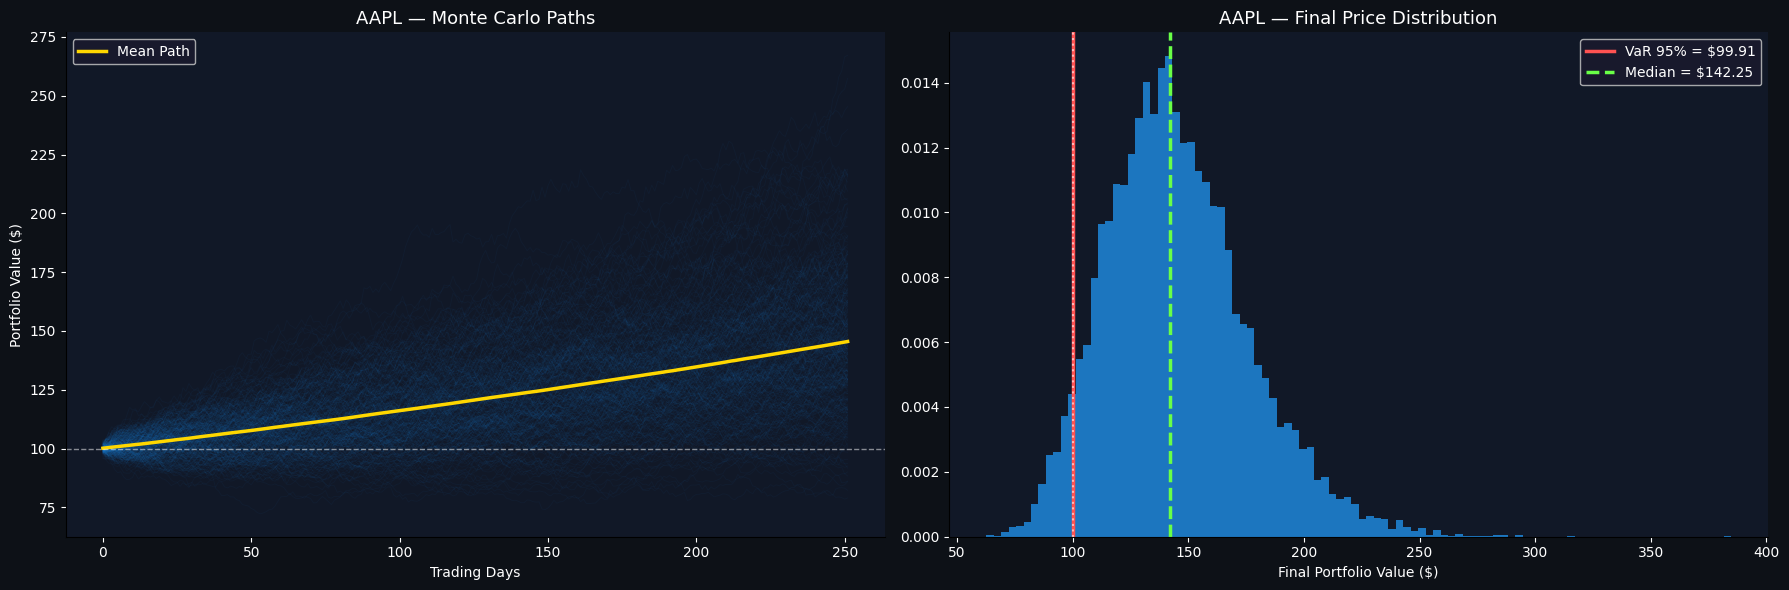

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

sample_idx = np.random.choice(MONTE_CARLO_RUNS, 300, replace=False)
for i in sample_idx:
    ax1.plot(all_paths[i], color='#2196F3', alpha=0.04, linewidth=0.7)
ax1.plot(all_paths.mean(axis=0), color='#FFD700', linewidth=2.5, label='Mean Path')
ax1.axhline(100, color='white', linewidth=1, linestyle='--', alpha=0.5)
ax1.set_title(f'{STOCK_TO_TEST} — Monte Carlo Paths', fontsize=13)
ax1.set_xlabel('Trading Days')
ax1.set_ylabel('Portfolio Value ($)')
ax1.legend(facecolor='#1a1a2e')

ax2.hist(final_prices, bins=100, color='#2196F3', alpha=0.75, density=True)
ax2.axvline(var_price, color='#FF5252', linewidth=2.5,
            label=f'VaR 95% = ${var_price:.2f}')
ax2.axvline(np.median(final_prices), color='#69FF47', linewidth=2.5, linestyle='--',
            label=f'Median = ${np.median(final_prices):.2f}')
ax2.axvline(100, color='white', linewidth=1.5, linestyle=':', alpha=0.6)
ax2.set_title(f'{STOCK_TO_TEST} — Final Price Distribution', fontsize=13)
ax2.set_xlabel('Final Portfolio Value ($)')
ax2.legend(facecolor='#1a1a2e')

plt.tight_layout()
plt.show()

---
## 🌡️ CELL 9 — Correlation Heatmap (Week 3)

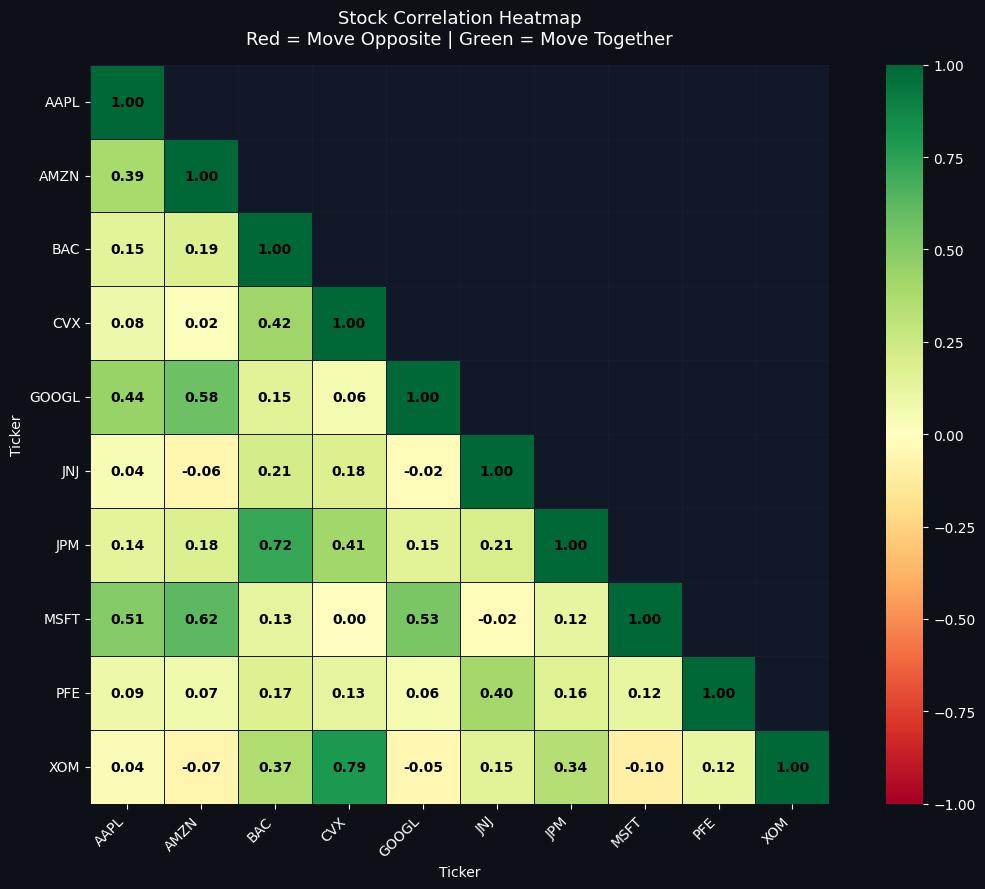


Top 3 Most Correlated:
         Pair  Correlation
 JPM <-> AMZN       0.7896
GOOGL <-> PFE       0.7228
 MSFT <-> XOM       0.6227

Top 3 Least Correlated (Best for Diversification):
         Pair  Correlation
 MSFT <-> JNJ      -0.0558
MSFT <-> AMZN      -0.0652
 XOM <-> AMZN      -0.0952


In [ ]:
corr_matrix = log_returns.corr(method='pearson')
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    corr_matrix, mask=mask,
    annot=True, fmt='.2f',
    cmap='RdYlGn', vmin=-1, vmax=1, center=0,
    square=True, linewidths=0.5, linecolor='#1a1a2e',
    annot_kws={'size': 10, 'weight': 'bold', 'color': 'black'},
    ax=ax
)
ax.set_title('Stock Correlation Heatmap\nRed = Move Opposite | Green = Move Together',
             fontsize=13, pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()

pairs = []
for i in range(len(STOCKS)):
    for j in range(i+1, len(STOCKS)):
        pairs.append({'Pair': f'{STOCKS[i]} <-> {STOCKS[j]}',
                      'Correlation': round(corr_matrix.iloc[i, j], 4)})
pairs_df = pd.DataFrame(pairs).sort_values('Correlation', ascending=False)
print('\nTop 3 Most Correlated:')
print(pairs_df.head(3).to_string(index=False))
print('\nTop 3 Least Correlated (Best for Diversification):')
print(pairs_df.tail(3).to_string(index=False))

---
## 📉 CELL 10 — Rolling Volatility (Week 3)

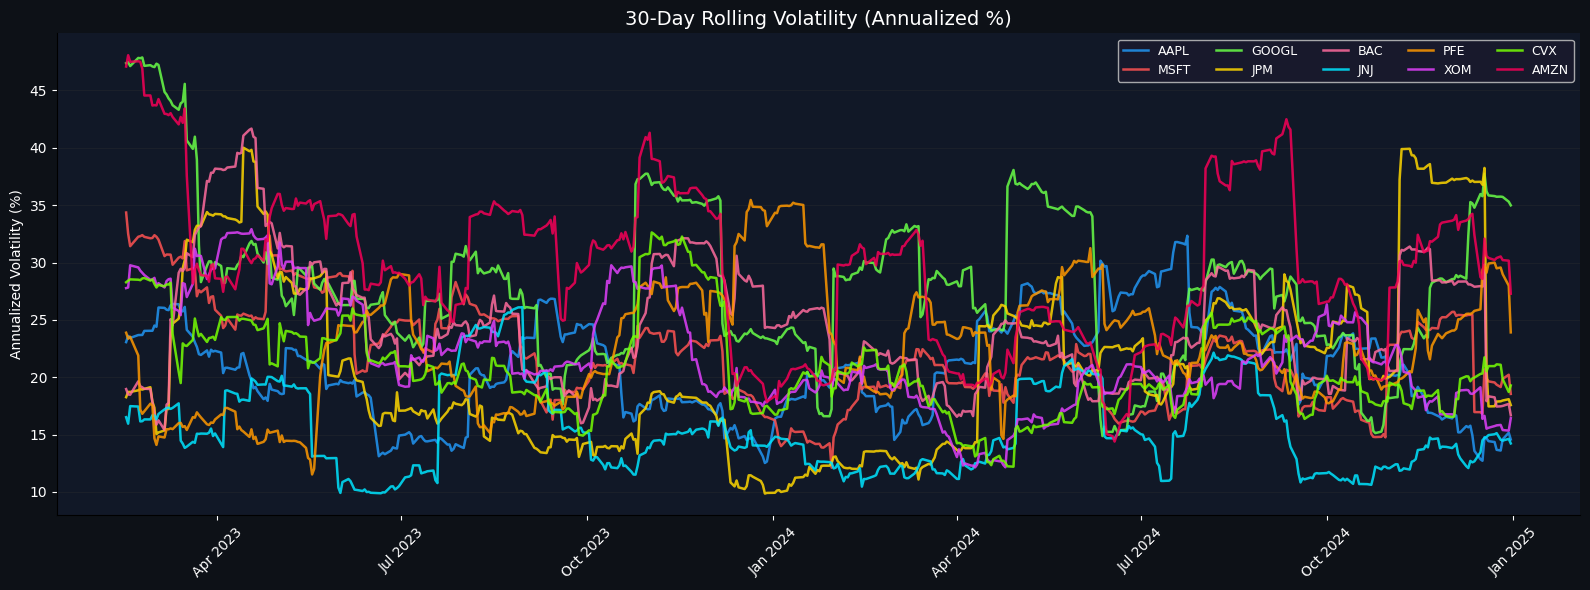


Volatility Ranking:
  AMZN     29.5%  ||||||||||||||
  GOOGL    28.1%  ||||||||||||||
  BAC      24.4%  ||||||||||||
  PFE      22.5%  |||||||||||
  MSFT     21.9%  ||||||||||
  XOM      21.8%  ||||||||||
  JPM      21.0%  ||||||||||
  AAPL     20.9%  ||||||||||
  CVX      20.7%  ||||||||||
  JNJ      15.3%  |||||||


In [15]:
rolling_vol = log_returns.rolling(window=ROLLING_WINDOW).std() * np.sqrt(252)
rolling_vol.dropna(inplace=True)

fig, ax = plt.subplots(figsize=(16, 6))
for i, stock in enumerate(STOCKS):
    ax.plot(rolling_vol.index, rolling_vol[stock] * 100,
            label=stock, color=COLORS[i], linewidth=1.8, alpha=0.85)

ax.set_title(f'{ROLLING_WINDOW}-Day Rolling Volatility (Annualized %)', fontsize=14)
ax.set_ylabel('Annualized Volatility (%)')
ax.legend(ncol=5, facecolor='#1a1a2e', fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('\nVolatility Ranking:')
avg_vol = (rolling_vol.mean() * 100).sort_values(ascending=False)
for stock, vol in avg_vol.items():
    print(f'  {stock:6s}  {vol:5.1f}%  {"|" * int(vol/2)}')

---
## 📋 CELL 11 — VaR + Max Drawdown + Sharpe (Week 4)

In [12]:
results = {}
risk_free_daily = 0.05 / 252

for stock in STOCKS:
    r      = log_returns[stock]
    prices = close_prices[stock].dropna()

    var_1d       = abs(np.percentile(r, 5)) * 100
    rolling_max  = prices.cummax()
    max_dd       = abs(((prices - rolling_max) / rolling_max).min()) * 100
    sharpe       = ((r.mean() - risk_free_daily) / r.std()) * np.sqrt(252)
    total_return = ((prices.iloc[-1] / prices.iloc[0]) - 1) * 100

    results[stock] = {
        'Total Return %': round(total_return, 2),
        'VaR 1D 95%':     round(var_1d, 3),
        'Max Drawdown %': round(max_dd, 2),
        'Sharpe Ratio':   round(sharpe, 4),
    }

summary_df = pd.DataFrame(results).T
print('====== ALPHAPULSE RISK SUMMARY ======')
display(summary_df.style
    .background_gradient(cmap='RdYlGn',   subset=['Total Return %', 'Sharpe Ratio'])
    .background_gradient(cmap='RdYlGn_r', subset=['VaR 1D 95%', 'Max Drawdown %'])
    .format('{:.2f}')
)

====== ALPHAPULSE RISK SUMMARY ======


,Total Return %,VaR 1D 95%,Max Drawdown %,Sharpe Ratio
AAPL,102.33,2.03,16.61,1.43
MSFT,78.82,2.29,15.49,1.07
GOOGL,113.18,2.57,22.14,1.13
JPM,87.06,1.83,13.49,1.20
BAC,38.68,2.38,29.97,0.46
JNJ,-13.73,1.56,17.43,-0.79
PFE,-42.59,2.30,47.71,-1.42
XOM,8.01,2.12,18.73,-0.05
CVX,-9.76,2.36,22.26,-0.48
AMZN,155.64,2.67,19.64,1.38


---
## 💾 CELL 12 — Save All Files to CSV (For Tableau)

In [ ]:
os.makedirs('../data/raw',        exist_ok=True)
os.makedirs('../data/processed',  exist_ok=True)
os.makedirs('../data/exports',    exist_ok=True)
os.makedirs('../outputs/charts',  exist_ok=True)
os.makedirs('../outputs/reports', exist_ok=True)

close_prices.to_csv('../data/raw/stock_data.csv')
log_returns.to_csv('../data/processed/log_returns.csv')
rolling_vol.to_csv('../data/processed/rolling_volatility.csv')
corr_matrix.to_csv('../data/processed/correlation_matrix.csv')

p = close_prices.reset_index().melt(id_vars='Date', var_name='Stock', value_name='Close_Price')
r = log_returns.reset_index().melt(id_vars='Date',  var_name='Stock', value_name='Log_Return')
v = rolling_vol.reset_index().melt(id_vars='Date',  var_name='Stock', value_name='Rolling_Vol')
tableau_df = p.merge(r, on=['Date','Stock']).merge(v, on=['Date','Stock'], how='left')
tableau_df['Daily_Return_Pct'] = tableau_df['Log_Return']  * 100
tableau_df['Rolling_Vol_Pct']  = tableau_df['Rolling_Vol'] * 100
tableau_df.to_csv('../data/exports/tableau_export.csv', index=False)

summary_df.to_csv('../outputs/reports/summary_metrics.csv')

print('Files saved:')
print('  data/raw/stock_data.csv')
print('  data/processed/log_returns.csv')
print('  data/processed/rolling_volatility.csv')
print('  data/processed/correlation_matrix.csv')
print('  data/exports/tableau_export.csv  <-- Import this into Tableau!')
print('  outputs/reports/summary_metrics.csv')
print('\nDone! Notebook complete.')

Files saved:
  data/raw/stock_data.csv
  data/processed/log_returns.csv
  data/processed/rolling_volatility.csv
  data/processed/correlation_matrix.csv
  data/exports/tableau_export.csv  <-- Import this into Tableau!
  outputs/reports/summary_metrics.csv

Done! Notebook complete.


---
## 🔍 CELL 13 — Single Stock Deep Dive

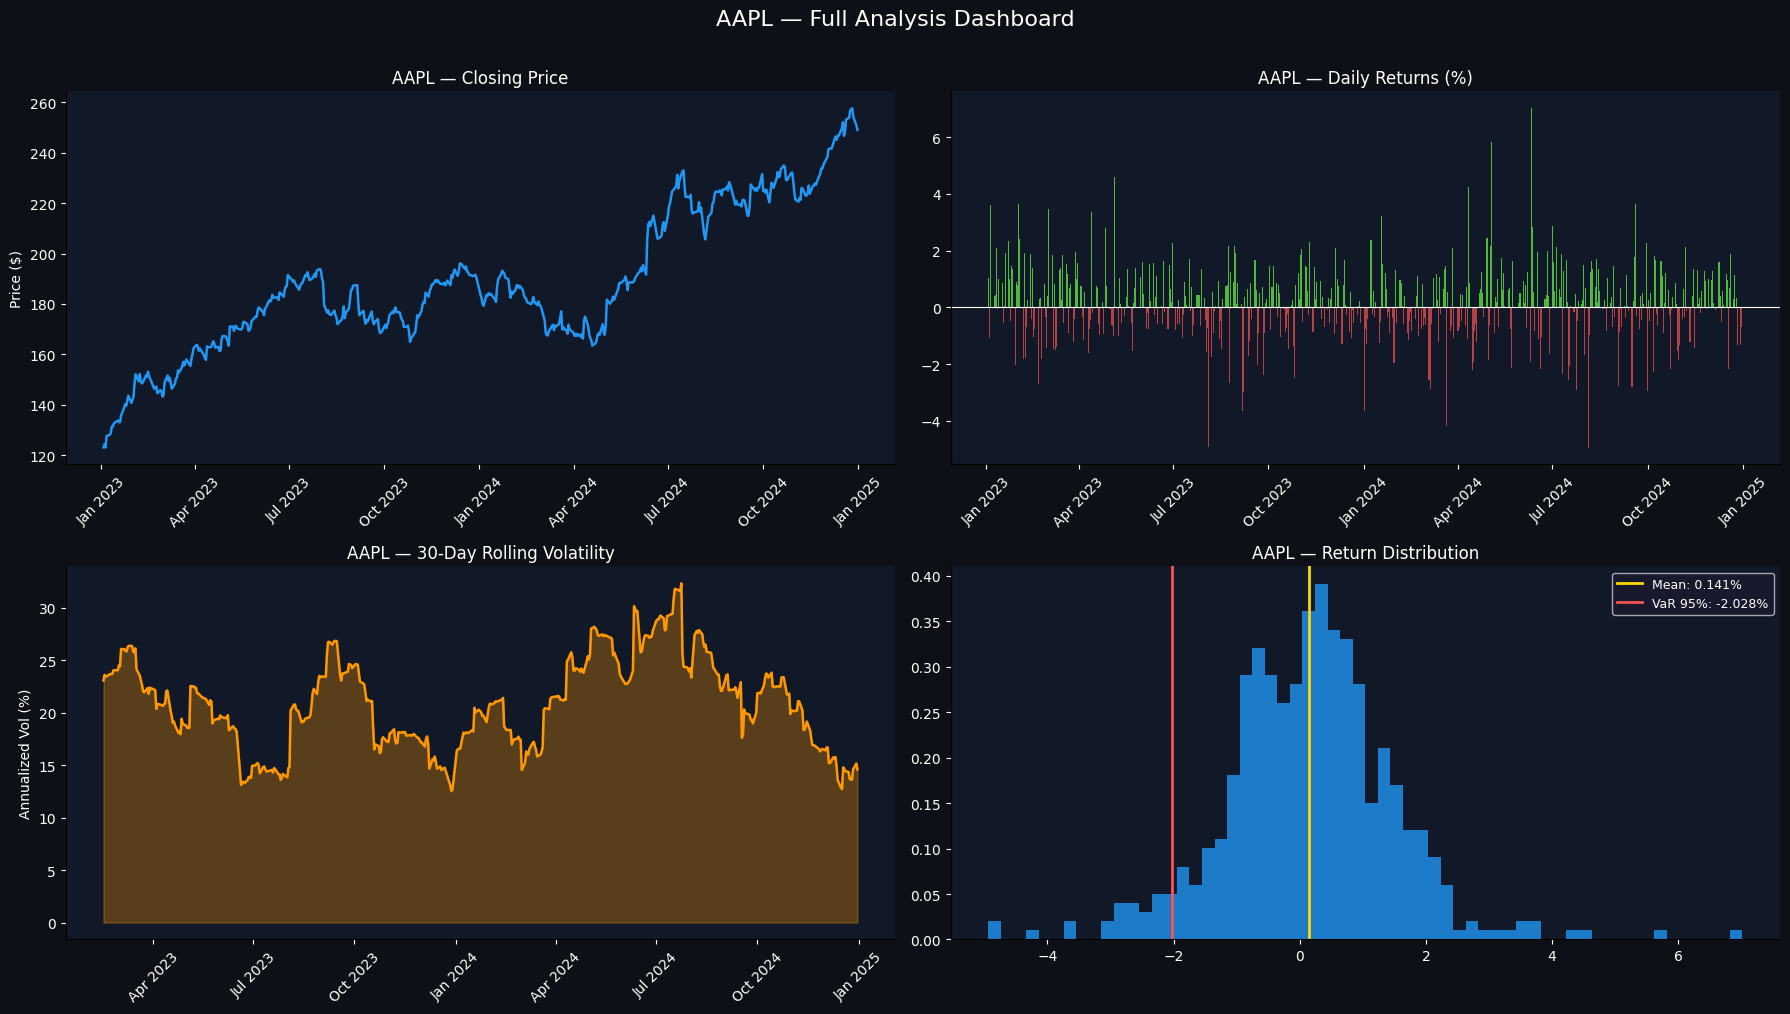

In [ ]:
FOCUS_STOCK = 'AAPL' 

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

ax = axes[0, 0]
ax.plot(close_prices.index, close_prices[FOCUS_STOCK], color='#2196F3', linewidth=1.8)
ax.set_title(f'{FOCUS_STOCK} — Closing Price')
ax.set_ylabel('Price ($)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

ax = axes[0, 1]
ret = log_returns[FOCUS_STOCK] * 100
bar_colors = ['#FF5252' if x < 0 else '#69FF47' for x in ret]
ax.bar(ret.index, ret, color=bar_colors, alpha=0.7, width=1)
ax.axhline(0, color='white', linewidth=0.8)
ax.set_title(f'{FOCUS_STOCK} — Daily Returns (%)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

ax = axes[1, 0]
vol = rolling_vol[FOCUS_STOCK] * 100
ax.fill_between(vol.index, vol, alpha=0.3, color='#FF9800')
ax.plot(vol.index, vol, color='#FF9800', linewidth=1.8)
ax.set_title(f'{FOCUS_STOCK} — 30-Day Rolling Volatility')
ax.set_ylabel('Annualized Vol (%)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

ax = axes[1, 1]
ax.hist(ret, bins=60, color='#2196F3', alpha=0.8, density=True)
ax.axvline(ret.mean(), color='#FFD700', linewidth=2, label=f'Mean: {ret.mean():.3f}%')
ax.axvline(np.percentile(ret, 5), color='#FF5252', linewidth=2,
           label=f'VaR 95%: {np.percentile(ret,5):.3f}%')
ax.set_title(f'{FOCUS_STOCK} — Return Distribution')
ax.legend(facecolor='#1a1a2e', fontsize=9)

fig.suptitle(f'{FOCUS_STOCK} — Full Analysis Dashboard', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()